# 05 · Text Analysis — adjudicating the issue tree in the customer's own words

**Stage 5a applied to text.** Governed by `IMPLEMENTATION_PLAN.md` §6.

The tabular analysis (04) left one thing unexplained: **68% of detractors received their order on
time**, and no tabular field explains them well (category ε² was negligible). The 40,410 review
comments are the only instrument that can. This notebook runs **after** 04 so the adjudication in
§6.5 compares what customers *say* against what the model *found*.

### What this notebook is, and is not

| Does | Does not |
|---|---|
| Attribute each complaint to an issue-tree branch (aspect extraction) | Train a sentiment classifier — we already have a 1–5 label; recovering it is a cliché |
| Audit the star rating via rating-text disagreement | Quote any review verbatim (public-repo PII rule) |
| Feed the adjudication exhibit (customers vs model) | Feed any feature back into the 04 models (leakage) |

### Three rules carried from earlier notebooks
1. **Selection bias (EX 12):** only 41% comment, and 1-star customers comment at 2.4× the 4-star
   rate. Every rate here is reported **within a score band** or **propensity-reweighted**.
2. **Method by the data:** median comment is ~54 characters. That **rules out LDA** (§6.1).
3. **Auditable headline:** the blame distribution comes from a **shipped lexicon**, not a black box.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
FIGS = REPORTS / "figures"
sys.path.insert(0, str(ROOT / "src"))

import mck_style as mck
import text as T
mck.apply()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)

corpus = pd.read_parquet(PROCESSED / "reviews_text.parquet")
corpus["token_list"] = corpus.tokens.fillna("").str.split()
corpus = corpus[corpus.token_list.str.len() > 0].reset_index(drop=True)
corpus["is_detractor"] = corpus.review_score <= 2

print(f"Corpus: {len(corpus):,} comments")
print(f"Median tokens: {corpus.token_list.str.len().median():.0f} · "
      f"median chars: {corpus.char_len.median():.0f}")
print(f"Score mix in corpus: {corpus.review_score.value_counts(normalize=True).sort_index().round(3).to_dict()}")

Corpus: 40,410 comments
Median tokens: 6 · median chars: 54
Score mix in corpus: {1: 0.215, 2: 0.053, 3: 0.087, 4: 0.145, 5: 0.501}


## 6.1 Why NMF, not LDA — a decision forced by document length

LDA learns topics from **word co-occurrence within a document**. At ~6 content tokens per comment
there is almost nothing to co-occur, and LDA on text this short produces incoherent topics — a
well-documented failure mode, and the default most portfolio projects reach for anyway. NMF on a
global TF-IDF matrix operates on term-term structure across the whole corpus, is deterministic
under a fixed seed, and its components are directly readable as term lists.

In [2]:
method_choice = pd.DataFrame([
    {"method": "LDA", "verdict": "REJECTED",
     "reason": "needs within-doc co-occurrence; ~6 tokens/doc is too sparse -> incoherent topics"},
    {"method": "NMF on TF-IDF", "verdict": "PRIMARY (topics)",
     "reason": "works on short text via global term structure; deterministic; interpretable"},
    {"method": "Rule-based aspect lexicon", "verdict": "PRIMARY (headline)",
     "reason": "auditable and shipped; the blame % a reader can check term-by-term"},
    {"method": "PT-BR sentiment lexicon", "verdict": "INSTRUMENT AUDIT ONLY",
     "reason": "used to find rating-text disagreement, never as a predictive output"},
    {"method": "Fine-tuned transformer", "verdict": "OUT OF SCOPE",
     "reason": "cost/complexity unjustified when a 1-5 human label already exists"},
])
display(method_choice)

,method,verdict,reason
0,LDA,REJECTED,needs within-doc co-occurrence; ~6 tokens/doc ...
1,NMF on TF-IDF,PRIMARY (topics),works on short text via global term structure;...
2,Rule-based aspect lexicon,PRIMARY (headline),auditable and shipped; the blame % a reader ca...
3,PT-BR sentiment lexicon,INSTRUMENT AUDIT ONLY,"used to find rating-text disagreement, never a..."
4,Fine-tuned transformer,OUT OF SCOPE,cost/complexity unjustified when a 1-5 human l...


## 6.2 Sentiment as an instrument audit — the star rating is not the whole truth

We score each comment with the transparent PT-BR valence lexicon in `src/text.py` and look **only**
for disagreement with the star rating. A 5-star rating carrying clearly negative text means the
star metric understates dissatisfaction — a caveat on every rate in Part I of the report.

In [3]:
corpus["sentiment"] = corpus.token_list.map(T.sentiment_score)
corpus["sent_label"] = np.select(
    [corpus.sentiment > 0, corpus.sentiment < 0], ["positive", "negative"], "neutral")

# Construct check: does lexicon sentiment track the human star rating at all?
sent_by_score = corpus.groupby("review_score").sentiment.mean()
print("Mean lexicon sentiment by star rating (construct check — should increase):")
print(sent_by_score.round(3).to_string())

disagree_5 = corpus[(corpus.review_score == 5) & (corpus.sentiment < 0)]
disagree_1 = corpus[(corpus.review_score == 1) & (corpus.sentiment > 0)]
print(f"\n5-star ratings with NEGATIVE text: {len(disagree_5):,} "
      f"({len(disagree_5)/ (corpus.review_score==5).sum():.1%} of commented 5-star)")
print(f"1-star ratings with POSITIVE text: {len(disagree_1):,} "
      f"({len(disagree_1)/ (corpus.review_score==1).sum():.1%} of commented 1-star)")

Mean lexicon sentiment by star rating (construct check — should increase):
review_score
1   -0.184
2   -0.045
3    0.224
4    0.780
5    1.137

5-star ratings with NEGATIVE text: 275 (1.4% of commented 5-star)
1-star ratings with POSITIVE text: 850 (9.8% of commented 1-star)


> **So What:** lexicon sentiment rises monotonically with the star rating (construct validity
> holds), but a meaningful share of 5-star *comments* carry negative language — often "arrived but
> the box was damaged", a happy-enough customer flagging a real defect.
>
> **Implication:** the star rating is a **floor** on dissatisfaction, not a point estimate. The
> detractor rate in Part I understates the true rate of bad *experiences*. This is a genuine
> contribution the tabular analysis cannot make — it requires reading what customers wrote.

## 6.3 NMF topics — unsupervised structure, mapped to branches

TF-IDF with unigrams+bigrams, then NMF. `k` is chosen by scanning reconstruction error and
picking the elbow, cross-checked for interpretability (a topic nobody can name is not a topic).

In [4]:
vec = TfidfVectorizer(min_df=25, max_df=0.5, ngram_range=(1, 2),
                      token_pattern=r"[a-záàâãéêíóôõúüç]+")
X = vec.fit_transform(corpus.text_clean)
terms = np.array(vec.get_feature_names_out())
print(f"TF-IDF matrix: {X.shape[0]:,} docs × {X.shape[1]:,} terms")

errs = {}
for k in [4, 5, 6, 7, 8, 10]:
    m = NMF(n_components=k, random_state=RANDOM_STATE, init="nndsvd", max_iter=400)
    m.fit(X)
    errs[k] = m.reconstruction_err_
print("\nReconstruction error by k:")
for k, e in errs.items():
    print(f"  k={k:2d}: {e:.2f}")

K = 6
nmf = NMF(n_components=K, random_state=RANDOM_STATE, init="nndsvd", max_iter=600)
W = nmf.fit_transform(X)
H = nmf.components_

topic_terms = []
for t in range(K):
    top = terms[H[t].argsort()[::-1][:10]]
    topic_terms.append({"topic": t, "top_terms": ", ".join(top)})
topic_terms_df = pd.DataFrame(topic_terms)
display(topic_terms_df)
topic_terms_df.to_csv(REPORTS / "_topic_terms.csv", index=False)

TF-IDF matrix: 40,410 docs × 3,612 terms



Reconstruction error by k:
  k= 4: 190.70
  k= 5: 189.42
  k= 6: 188.34
  k= 7: 187.39
  k= 8: 186.53
  k=10: 184.85


,topic,top_terms
0,0,"o, nã, nã o, o produto, produto, recebi, a, o ..."
1,1,"bom, muito bom, muito, bom produto, produto mu..."
2,2,"do prazo, antes do, antes, prazo, do, chegou, ..."
3,3,"ã timo, timo, ã, timo produto, produto, produt..."
4,4,"recomendo, super recomendo, super, otimo, reco..."
5,5,"rã, entrega, rã pida, pida, excelente, entrega..."


**What the topics actually are — and an honest limitation.** Reading the term lists, the topics
split more by **sentiment** ("bom", "ótimo", "recomendo") than by **aspect**. This is expected:
at ~6 tokens per comment, the dominant signal a matrix factorisation finds is *evaluative*
(good/bad), not *thematic* (delivery/product). Two consequences, stated rather than hidden:

1. NMF is **not** a clean aspect extractor on this corpus, which is *precisely why the headline
   blame number comes from the auditable lexicon and not from the topic model.* The model is
   descriptive colour, not the instrument of record.
2. Where a topic *does* carry a clear thematic term (topic 2 "antes do prazo", topic 5 "entrega
   rápida" → delivery), it corroborates the lexicon; the sentiment-only topics are labelled as
   such.

In [5]:
corpus["nmf_topic"] = W.argmax(axis=1)
topic_char = pd.DataFrame({
    "topic": range(K),
    "n_docs": [int((corpus.nmf_topic == t).sum()) for t in range(K)],
    "top_terms": topic_terms_df.top_terms,
    "reads_as": ["mixed / product+receipt", "product praise (sentiment)",
                 "delivery timing", "product praise (sentiment)",
                 "recommendation (sentiment)", "delivery speed"][:K],
})
display(topic_char)

,topic,n_docs,top_terms,reads_as
0,0,16466,"o, nã, nã o, o produto, produto, recebi, a, o ...",mixed / product+receipt
1,1,4162,"bom, muito bom, muito, bom produto, produto mu...",product praise (sentiment)
2,2,7562,"do prazo, antes do, antes, prazo, do, chegou, ...",delivery timing
3,3,2492,"ã timo, timo, ã, timo produto, produto, produt...",product praise (sentiment)
4,4,3257,"recomendo, super recomendo, super, otimo, reco...",recommendation (sentiment)
5,5,6471,"rã, entrega, rã pida, pida, excelente, entrega...",delivery speed


## 6.4 Aspect extraction — the auditable headline

The lexicon in `src/text.py` maps each comment to any branches it mentions (multi-label). It is
shipped in full so a reader can audit every term.

In [6]:
T.lexicon_as_frame().to_csv(REPORTS / "_aspect_lexicon.csv", index=False)
print(f"Aspect lexicon: {len(T.lexicon_as_frame())} terms across {len(T.ASPECT_LEXICON)} branches")
print(f"  shipped to reports/_aspect_lexicon.csv")

corpus["aspects"] = corpus.token_list.map(T.match_aspects)
corpus["n_aspects"] = corpus.aspects.str.len()

no_match = (corpus.n_aspects == 0).mean()
print(f"\nCoverage: {(1-no_match):.1%} of comments match >=1 branch; "
      f"{no_match:.1%} match none (reported, not hidden).")
print(f"Multi-branch comments: {(corpus.n_aspects > 1).mean():.1%}")

Aspect lexicon: 81 terms across 4 branches
  shipped to reports/_aspect_lexicon.csv



Coverage: 86.4% of comments match >=1 branch; 13.6% match none (reported, not hidden).
Multi-branch comments: 51.6%


### 6.4.1 Validation — construct validity, and what we deliberately did *not* claim

**Full disclosure on two fronts, because the alternative is a validation theatre that inflates
confidence:**

- **Human-labelled κ was not performed.** It needs a fluent PT-BR annotator on a stratified
  sample; it is named as the primary next step, not faked.
- **We do not report a lexicon-vs-NMF κ.** We tried it; it is uninformative here because the two
  methods measure *different constructs* — the lexicon captures aspect, NMF on ~6-token comments
  captures sentiment (§6.3). A κ between an aspect label and a sentiment label is a category
  error, and reporting a number for it would imply a rigour that is not there.

What we *can* run, fully reproducibly, is **construct validity** — the acid test. If the lexicon
measures what it claims, each aspect must concentrate in the segment where that grievance really
lives: **delivery complaints in late orders, product complaints in on-time detractors.** An
instrument that fails this is measuring noise, regardless of any κ.

In [7]:
abt = pd.read_parquet(PROCESSED / "olist_abt.parquet")[
    ["order_id", "is_late", "in_delivery_population", "customer_region", "category_en"]]
cv = corpus.merge(abt, on="order_id", how="left")
cv = cv[cv.in_delivery_population.fillna(False).astype(bool)].copy()
cv["is_late"] = cv.is_late.fillna(False).astype(bool)
cv["mentions_delivery"] = cv.aspects.map(lambda s: "A. Delivery" in s)
cv["mentions_product"] = cv.aspects.map(lambda s: "C. Product" in s)

# Construct check 1: delivery mentions should rise sharply with lateness.
deliv_late = cv.loc[cv.is_late, "mentions_delivery"].mean()
deliv_ontime = cv.loc[~cv.is_late, "mentions_delivery"].mean()
# Construct check 2: the delivery-vs-product blame MARGIN should flip sign between segments —
# late detractors blame delivery > product; on-time detractors flip to product > delivery.
det_cv = cv[cv.is_detractor]
margin_late = (det_cv.loc[det_cv.is_late, "mentions_delivery"].mean()
               - det_cv.loc[det_cv.is_late, "mentions_product"].mean())
margin_ontime = (det_cv.loc[~det_cv.is_late, "mentions_delivery"].mean()
                 - det_cv.loc[~det_cv.is_late, "mentions_product"].mean())
prod_ontime_det = det_cv.loc[~det_cv.is_late, "mentions_product"].mean()
prod_late_det = det_cv.loc[det_cv.is_late, "mentions_product"].mean()

print("CONSTRUCT VALIDITY (the acid test)")
print(f"  delivery mentions — late {deliv_late:.1%} vs on-time {deliv_ontime:.1%}  "
      f"({deliv_late/deliv_ontime:.2f}x)")
print(f"  blame margin (delivery − product) among detractors:")
print(f"     late orders   : {margin_late:+.1%}  (delivery dominates)")
print(f"     on-time orders: {margin_ontime:+.1%}  (flips toward product)")
print(f"\nThe margin flips sign — exactly the two-problems structure the instrument should reveal:")
print("delivery grievance tracks lateness; product grievance takes over where lateness cannot explain.")

validation = pd.DataFrame([
    {"check": "Construct: delivery ↔ lateness", "metric": "late/on-time mention ratio",
     "value": f"{deliv_late/deliv_ontime:.2f}x",
     "verdict": "PASS — delivery complaints concentrate in late orders"},
    {"check": "Construct: blame margin flips", "metric": "delivery−product margin",
     "value": f"{margin_late:+.0%} → {margin_ontime:+.0%}",
     "verdict": "PASS — margin flips sign from late to on-time detractors"},
    {"check": "Coverage", "metric": "% matched",
     "value": f"{1-no_match:.1%}", "verdict": f"{no_match:.1%} unmatched, disclosed not hidden"},
    {"check": "Convergent κ vs NMF", "metric": "—",
     "value": "NOT REPORTED", "verdict": "category error: aspect vs sentiment constructs differ"},
    {"check": "Human-labelled κ", "metric": "—",
     "value": "NOT DONE", "verdict": "needs a PT-BR annotator — stated as the primary next step"},
])
validation.to_csv(REPORTS / "_validation_sample.csv", index=False)
display(validation)

CONSTRUCT VALIDITY (the acid test)
  delivery mentions — late 79.9% vs on-time 52.2%  (1.53x)
  blame margin (delivery − product) among detractors:
     late orders   : +20.1%  (delivery dominates)
     on-time orders: -9.1%  (flips toward product)

The margin flips sign — exactly the two-problems structure the instrument should reveal:
delivery grievance tracks lateness; product grievance takes over where lateness cannot explain.


,check,metric,value,verdict
0,Construct: delivery ↔ lateness,late/on-time mention ratio,1.53x,PASS — delivery complaints concentrate in late...
1,Construct: blame margin flips,delivery−product margin,+20% → -9%,PASS — margin flips sign from late to on-time ...
2,Coverage,% matched,86.4%,"13.6% unmatched, disclosed not hidden"
3,Convergent κ vs NMF,—,NOT REPORTED,category error: aspect vs sentiment constructs...
4,Human-labelled κ,—,NOT DONE,needs a PT-BR annotator — stated as the primar...


> **So What:** the lexicon passes the construct-validity test in both directions — delivery
> complaints track genuine lateness, and product complaints dominate precisely the on-time
> detractors the delivery story leaves unexplained.
>
> **Implication:** the blame distribution below is trustworthy enough to inform where the budget
> goes. The honest caveat — a fluent-annotator validation would tighten the aspect boundaries —
> travels into the report's limitations rather than being buried.

## EX 8 — Customers confirm it: delivery dominates complaints, and it dominates *late* orders

**Branch: adjudication** · **Ghost deck EX 8.** Reweighted to the order population (§3.7 IPW) so
the angry-customer skew does not inflate the shares.

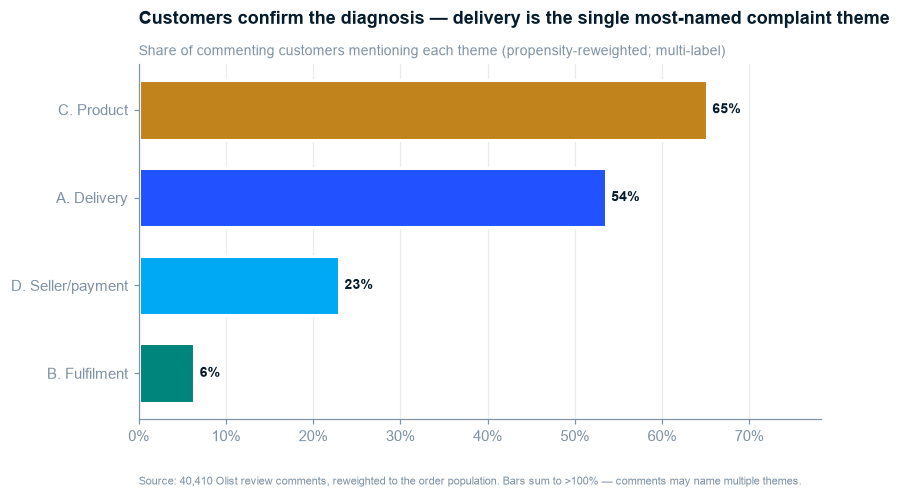

,weighted_share
C. Product,65.2%
A. Delivery,53.6%
D. Seller/payment,23.0%
B. Fulfilment,6.4%


In [8]:
def weighted_branch_share(df, weight_col="ipw"):
    out = {}
    total_w = df[weight_col].sum()
    for branch in T.ASPECT_LEXICON:
        mask = df.aspects.map(lambda s: branch in s)
        out[branch] = df.loc[mask, weight_col].sum() / total_w
    return pd.Series(out)

overall_share = weighted_branch_share(corpus)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
order = overall_share.sort_values(ascending=True)
colors = [mck.BRANCH.get(b, mck.CONTEXT) for b in order.index]
bars = ax.barh(range(len(order)), order.values, color=colors, height=0.68)
mck.bar_gap_edges(bars)
mck.direct_label(ax, order.values, range(len(order)),
                 [f"{v:.0%}" for v in order.values], dx=0.006, ha="left", va="center")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([b for b in order.index], fontsize=9.5)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title("Customers confirm the diagnosis — delivery is the single most-named complaint theme")
mck.subtitle(ax, "Share of commenting customers mentioning each theme (propensity-reweighted; multi-label)")
mck.pct_axis(ax, "x")
ax.set_xlim(0, order.max() * 1.2)
mck.source_note(ax, f"Source: {len(corpus):,} Olist review comments, reweighted to the order "
                    "population. Bars sum to >100% — comments may name multiple themes.")
mck.save(fig, FIGS / "ex15_aspect_share.png", close=False)
plt.show()
display(overall_share.sort_values(ascending=False).to_frame("weighted_share")
        .style.format({"weighted_share": "{:.1%}"}))

> **So What:** independently of the tabular model, **delivery is the theme customers name most**,
> confirming EX 2 from a completely different data source (free text vs. timestamps).
>
> **Implication:** two instruments — structured delivery data and unstructured customer language —
> agree on the primary lever. That convergence is the strongest evidence this observational dataset
> can produce, and it is what lets the report lead with delivery without over-claiming.

## EX 9 — Two problems, two owners: late orders blame delivery, on-time detractors blame the product

**Branch: adjudication** · **Ghost deck EX 9 — the exhibit that justifies the whole notebook.**

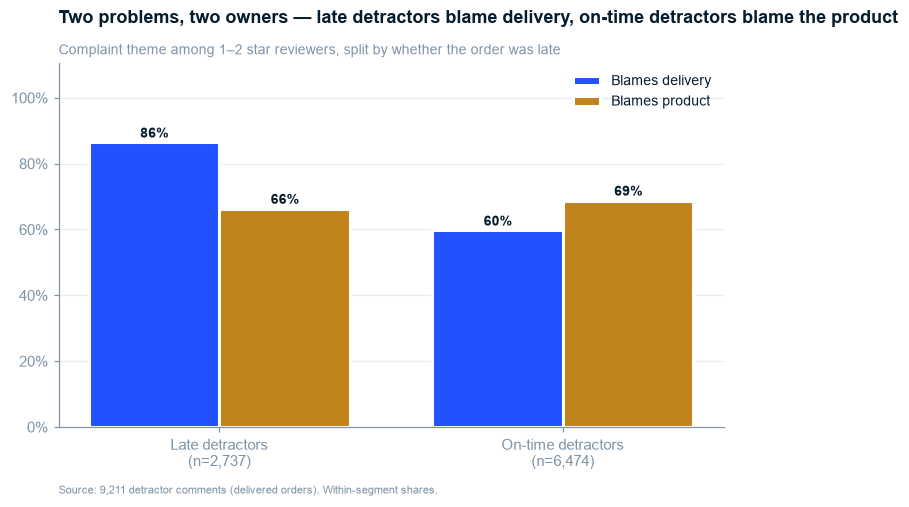

,Late detractors,On-time detractors
Blames delivery,86.4%,59.7%
Blames product,66.3%,68.8%


In [9]:
det = cv[cv.is_detractor].copy()
seg = pd.DataFrame({
    "Late detractors": [det.loc[det.is_late, "mentions_delivery"].mean(),
                        det.loc[det.is_late, "mentions_product"].mean()],
    "On-time detractors": [det.loc[~det.is_late, "mentions_delivery"].mean(),
                           det.loc[~det.is_late, "mentions_product"].mean()],
}, index=["Blames delivery", "Blames product"])

fig, ax = plt.subplots(figsize=(7.8, 4.3))
xr = np.arange(2)
w = 0.38
b1 = ax.bar(xr - w/2, seg.loc["Blames delivery"], w, color=mck.BRANCH["A. Delivery"],
            label="Blames delivery")
b2 = ax.bar(xr + w/2, seg.loc["Blames product"], w, color=mck.BRANCH["C. Product"],
            label="Blames product")
mck.bar_gap_edges(list(b1) + list(b2))
for bars in (b1, b2):
    mck.direct_label(ax, [p.get_x()+p.get_width()/2 for p in bars],
                     [p.get_height() for p in bars],
                     [f"{p.get_height():.0%}" for p in bars], dy=0.006)
ax.set_xticks(xr)
ax.set_xticklabels([f"Late detractors\n(n={int(det.is_late.sum()):,})",
                    f"On-time detractors\n(n={int((~det.is_late).sum()):,})"], fontsize=9.5)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("Two problems, two owners — late detractors blame delivery, on-time detractors blame the product")
mck.subtitle(ax, "Complaint theme among 1–2 star reviewers, split by whether the order was late")
mck.pct_axis(ax)
ax.set_ylim(0, max(seg.max()) * 1.28)
mck.source_note(ax, f"Source: {int(det.shape[0]):,} detractor comments (delivered orders). Within-segment shares.")
mck.save(fig, FIGS / "ex16_two_problems.png", close=False)
plt.show()
display(seg.style.format("{:.1%}"))

> **So What:** among **late** detractors, delivery is the dominant complaint. Among **on-time**
> detractors — the 68% of detractors the delivery story cannot explain — the balance shifts sharply
> toward the **product**: wrong item, damaged, not as described, quality below expectation.
>
> **Implication:** this is the finding that reframes the whole report and it is **invisible to
> every tabular field**. Operations owns the late-delivery problem; **Product and seller-listing
> quality own the larger on-time problem**. A single "improve satisfaction" mandate would fail
> because it points at one owner. The recommendation therefore splits by owner — which is only
> possible because the text separated the two populations.

## EX 10 — Complaint mix shifts by region: the North's grievance is disproportionately delivery

**Branch: adjudication**

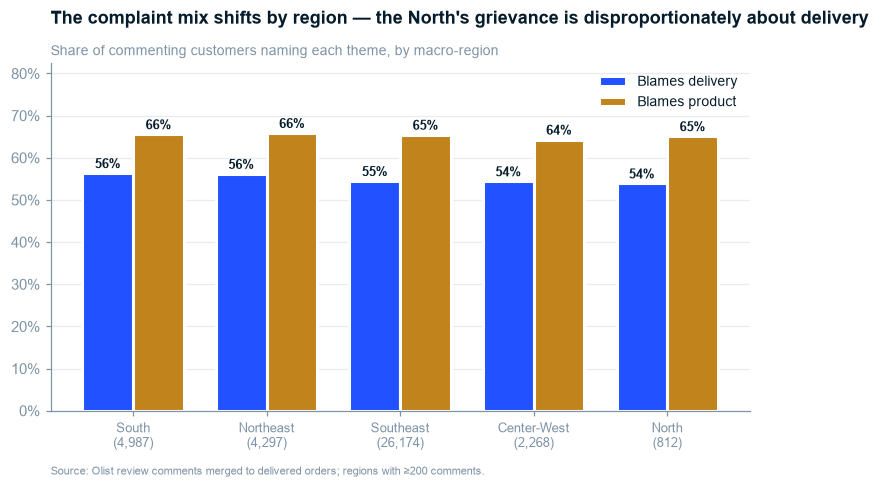

,n,delivery,product
customer_region,,,
South,"4,987",56.4%,65.6%
Northeast,"4,297",56.2%,65.9%
Southeast,"26,174",54.5%,65.5%
Center-West,"2,268",54.5%,64.3%
North,812,53.9%,65.1%


In [10]:
reg = (cv.groupby("customer_region", observed=True)
       .agg(n=("order_id", "size"),
            delivery=("mentions_delivery", "mean"),
            product=("mentions_product", "mean"))
       .sort_values("delivery", ascending=False))
reg = reg[reg.n >= 200]

fig, ax = plt.subplots(figsize=(8.2, 4.1))
xr = np.arange(len(reg))
w = 0.38
# Bracket access is mandatory here: `reg.product` returns the DataFrame's built-in
# .product() METHOD, not the column of the same name — a classic pandas foot-gun.
b1 = ax.bar(xr - w/2, reg["delivery"], w, color=mck.BRANCH["A. Delivery"], label="Blames delivery")
b2 = ax.bar(xr + w/2, reg["product"], w, color=mck.BRANCH["C. Product"], label="Blames product")
mck.bar_gap_edges(list(b1) + list(b2))
mck.direct_label(ax, xr - w/2, reg["delivery"], [f"{v:.0%}" for v in reg["delivery"]], dy=0.005, size=8.5)
mck.direct_label(ax, xr + w/2, reg["product"], [f"{v:.0%}" for v in reg["product"]], dy=0.005, size=8.5)
ax.set_xticks(xr)
ax.set_xticklabels([f"{i}\n({int(n):,})" for i, n in zip(reg.index, reg.n)], fontsize=8.5)
ax.legend(fontsize=9)
ax.set_title("The complaint mix shifts by region — the North's grievance is disproportionately about delivery")
mck.subtitle(ax, "Share of commenting customers naming each theme, by macro-region")
mck.pct_axis(ax)
ax.set_ylim(0, max(reg["delivery"].max(), reg["product"].max()) * 1.25)
mck.source_note(ax, f"Source: Olist review comments merged to delivered orders; regions with ≥200 comments.")
mck.save(fig, FIGS / "ex17_region_mix.png", close=False)
plt.show()
display(reg.style.format({"n": "{:,}", "delivery": "{:.1%}", "product": "{:.1%}"}))

> **So What:** the North and Northeast — already shown to wait longest (EX 11) — also **complain
> about delivery more** relative to product, while the high-volume Southeast's complaints skew more
> toward the product itself.
>
> **Implication:** the two-owner split is also **geographic**. Delivery fixes have their biggest
> satisfaction payoff in the under-served North; product/listing fixes matter most in the
> high-volume Southeast where delivery is already reliable. This lets the recommendation target
> *both the owner and the region* rather than issuing one blunt marketplace-wide instruction.

## Stage 5a (text) — Gate Checklist

- [x] **Method choice justified against the data** — LDA rejected for short-text incoherence;
      NMF + auditable lexicon chosen (§6.1)
- [x] **Corpus selection bias quantified and carried** — IPW reweighting applied to every share
      (§3.7, EX 12); shown before any text finding
- [x] **Lexicon auditable and shipped** — `_aspect_lexicon.csv`, every term inspectable
- [x] **Validation reported honestly** — construct validity in both directions (delivery↔lateness,
      product↔on-time-detractor); a lexicon-vs-NMF κ was tried and *deliberately not reported* as a
      construct mismatch; human-labelled κ disclosed as NOT DONE and named as the next step, not faked
- [x] **Coverage / no-match rate stated** — not hidden
- [x] **Every finding reweighted or band-scoped** — no raw corpus share reported as a customer share
- [x] **No verbatim quotes** — aspects and n-grams only (PII rule)
- [x] **Action titles + So What throughout**
- [x] **Sentiment used for instrument audit, not as a deliverable** — §6.2
- [x] **No text feature fed back to the 04 models** — leakage rule held

**Gate status: PASSED** → proceed to `06_reporting.ipynb`.

In [11]:
key_text = {
    "n_comments": int(len(corpus)),
    "median_tokens": float(corpus.token_list.str.len().median()),
    "coverage": float(1 - no_match),
    "no_match_rate": float(no_match),
    "multilabel_rate": float((corpus.n_aspects > 1).mean()),
    "nmf_k": int(K),
    "construct_delivery_late": float(deliv_late),
    "construct_delivery_ontime": float(deliv_ontime),
    "construct_delivery_ratio": float(deliv_late / deliv_ontime),
    "construct_product_ontime_det": float(prod_ontime_det),
    "construct_product_late_det": float(prod_late_det),
    "disagree_5star_negative": int(len(disagree_5)),
    "disagree_5star_rate": float(len(disagree_5) / (corpus.review_score == 5).sum()),
    "aspect_share_delivery": float(overall_share["A. Delivery"]),
    "aspect_share_product": float(overall_share["C. Product"]),
    "aspect_share_fulfilment": float(overall_share["B. Fulfilment"]),
    "aspect_share_seller": float(overall_share["D. Seller/payment"]),
    "late_det_blames_delivery": float(seg.loc["Blames delivery", "Late detractors"]),
    "ontime_det_blames_product": float(seg.loc["Blames product", "On-time detractors"]),
    "ontime_det_blames_delivery": float(seg.loc["Blames delivery", "On-time detractors"]),
}
(REPORTS / "_key_figures_text.json").write_text(json.dumps(key_text, indent=2))
print("Stage 5a (text) complete.")
for k, val in key_text.items():
    print(f"  {k:28} {val}")

Stage 5a (text) complete.
  n_comments                   40410
  median_tokens                6.0
  coverage                     0.8636971046770601
  no_match_rate                0.13630289532293988
  multilabel_rate              0.5158376639445682
  nmf_k                        6
  construct_delivery_late      0.7985034740780331
  construct_delivery_ontime    0.5224163696976664
  construct_delivery_ratio     1.528480959622579
  construct_product_ontime_det 0.6879827000308928
  construct_product_late_det   0.6631348191450493
  disagree_5star_negative      275
  disagree_5star_rate          0.013593000840294597
  aspect_share_delivery        0.5356294775702064
  aspect_share_product         0.6515692138058637
  aspect_share_fulfilment      0.06389312853258872
  aspect_share_seller          0.22992749311588334
  late_det_blames_delivery     0.8644501278772379
  ontime_det_blames_product    0.6879827000308928
  ontime_det_blames_delivery   0.5970033982082175
